# The Anatomy of a Hit Song
## A Data-Driven Analysis of 114,000 Spotify Tracks

### Objective
The goal of this project is to analyze Spotify track data and investigate whether audio features such as danceability, energy, loudness, tempo, and genre influence song popularity.

In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the Dataset

In [105]:
df = pd.read_csv("dataset.csv",low_memory=False)
print("Shape:", df.shape)
df.head()

Shape: (54043, 21)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666.0,False,0.676,0.4610,...,-6.746,0.0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4.0,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610.0,False,0.420,0.1660,...,-17.235,1.0,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4.0,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826.0,False,0.438,0.3590,...,-9.734,1.0,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4.0,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933.0,False,0.266,0.0596,...,-18.515,1.0,0.0363,0.9050,0.000071,0.1320,0.143,181.74,3.0,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853.0,False,0.618,0.4430,...,-9.681,1.0,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4.0,acoustic


## Dataset Overview

In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54043 entries, 0 to 54042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        54043 non-null  int64  
 1   track_id          54043 non-null  object 
 2   artists           54043 non-null  object 
 3   album_name        54043 non-null  object 
 4   track_name        54043 non-null  object 
 5   popularity        54042 non-null  object 
 6   duration_ms       54042 non-null  float64
 7   explicit          54042 non-null  object 
 8   danceability      54042 non-null  float64
 9   energy            54042 non-null  float64
 10  key               54042 non-null  float64
 11  loudness          54042 non-null  float64
 12  mode              54042 non-null  float64
 13  speechiness       54042 non-null  float64
 14  acousticness      54042 non-null  float64
 15  instrumentalness  54042 non-null  float64
 16  liveness          54042 non-null  float6

In [107]:
df.isnull().sum()

,0
Unnamed: 0,0
track_id,0
artists,0
album_name,0
track_name,0
popularity,1
duration_ms,1
explicit,1
danceability,1
energy,1


In [108]:
df.duplicated().sum()

np.int64(6199)

## Data Cleaning

In [109]:
df = df.dropna()
print(df.shape)

(54041, 21)


In [110]:
df = df.drop("Unnamed: 0", axis=1)
#In Pandas, axis=0 represents rows and axis=1 represents columns.
print(df.shape)

(54041, 20)


## Distribution of Song Popularity

This visualization shows how popularity scores are distributed across Spotify tracks.

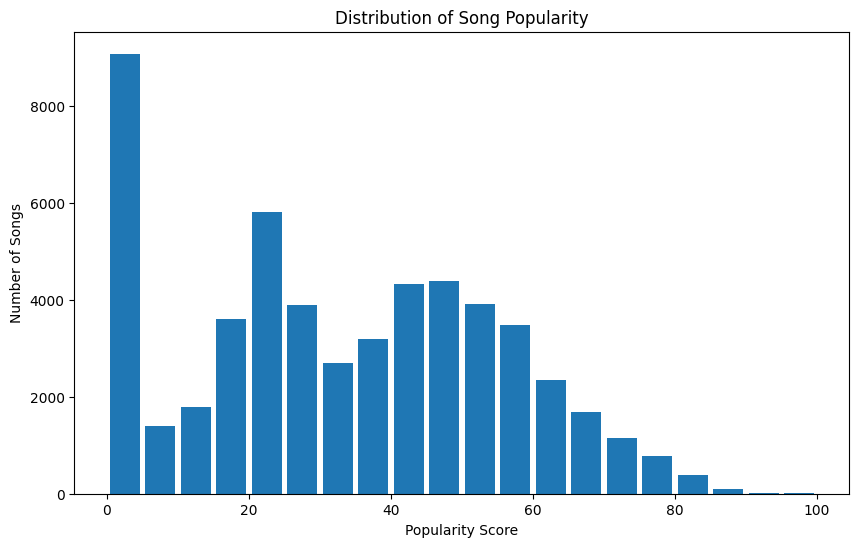

In [111]:
# Convert popularity to numeric, turning any broken/text values into NaN
df["popularity"] = pd.to_numeric(df["popularity"], errors="coerce")
plt.figure(figsize=(10, 6))
plt.hist(
    df["popularity"],
    bins=20,
    rwidth=0.85
)
plt.title("Distribution of Song Popularity")
plt.xlabel("Popularity Score")
plt.ylabel("Number of Songs")
plt.show()

## Summary Statistics

In [112]:
df["popularity"].describe()

,popularity
count,54041.000000
mean,32.676542
std,22.071152
min,0.000000
25%,17.000000
50%,32.000000
75%,50.000000
max,100.000000


## Correlation Analysis

This analysis explores the relationship between popularity and various audio features.

In [113]:
numeric_cols = [
    "popularity",
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

corr_matrix = df[numeric_cols].corr()
corr_matrix["popularity"].sort_values(ascending=False)

,popularity
popularity,1.000000
loudness,0.059735
danceability,0.034468
tempo,0.009673
acousticness,0.005109
energy,-0.046644
valence,-0.048429
liveness,-0.055415
speechiness,-0.071376
instrumentalness,-0.122169


## Correlation Heatmap

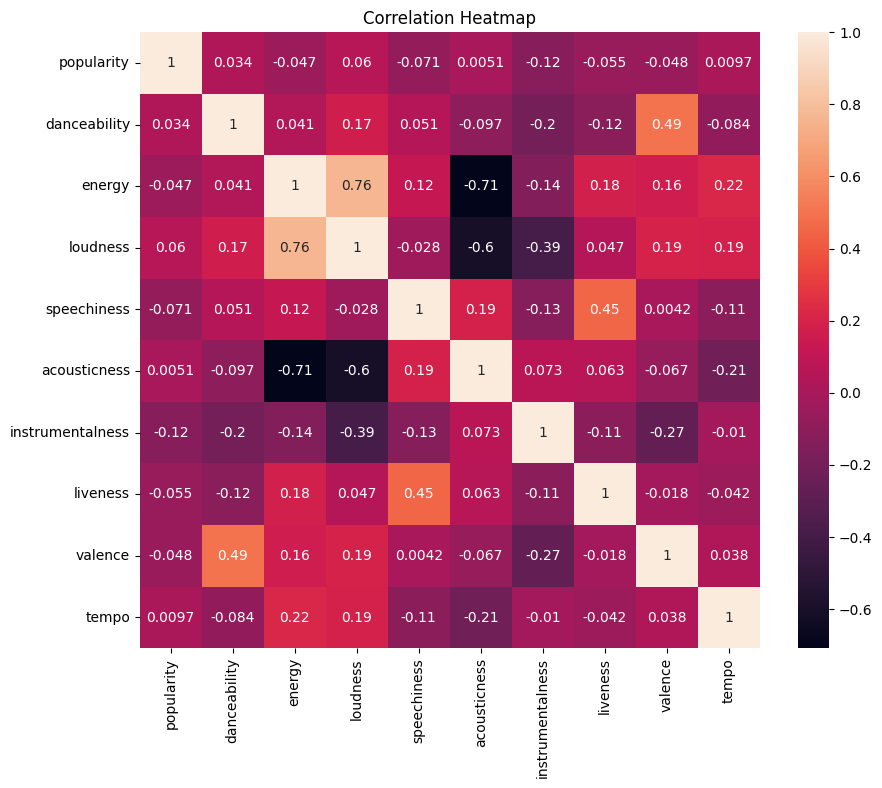

In [114]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True
)

plt.title("Correlation Heatmap")

plt.show()

## Explicit vs Non-Explicit Songs

This analysis compares the average popularity of songs containing explicit lyrics with non-explicit songs.

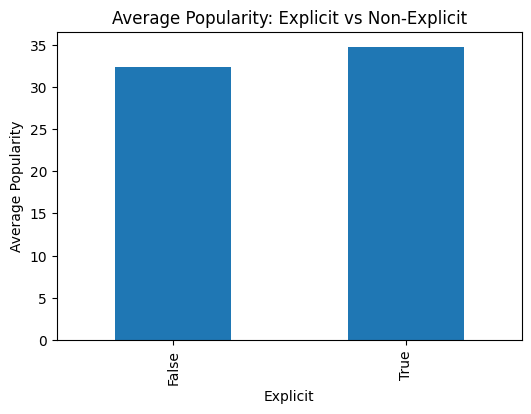

In [115]:
explicit_popularity = df.groupby("explicit")["popularity"].mean() #explicit lyrics used in song
# group 'explicit' column as True and False(2 groups) and
# then calculate mean population of each group
# Pandas Series is created

plt.figure(figsize=(6,4))
explicit_popularity.plot(kind="bar")

plt.title("Average Popularity: Explicit vs Non-Explicit")
plt.xlabel("Explicit")
plt.ylabel("Average Popularity")

plt.show()

## Top Genres by Popularity

In [116]:
genre_popularity = (
    df.groupby("track_genre")["popularity"]
      .mean()
      .sort_values(ascending=False)
) # Pandas Series is created
genre_popularity.head(10)

,popularity
track_genre,
chill,53.651000
grunge,49.594000
anime,48.772000
emo,48.128000
deep-house,44.969055
brazil,44.670000
electronic,44.325000
ambient,44.191000
british,43.802000


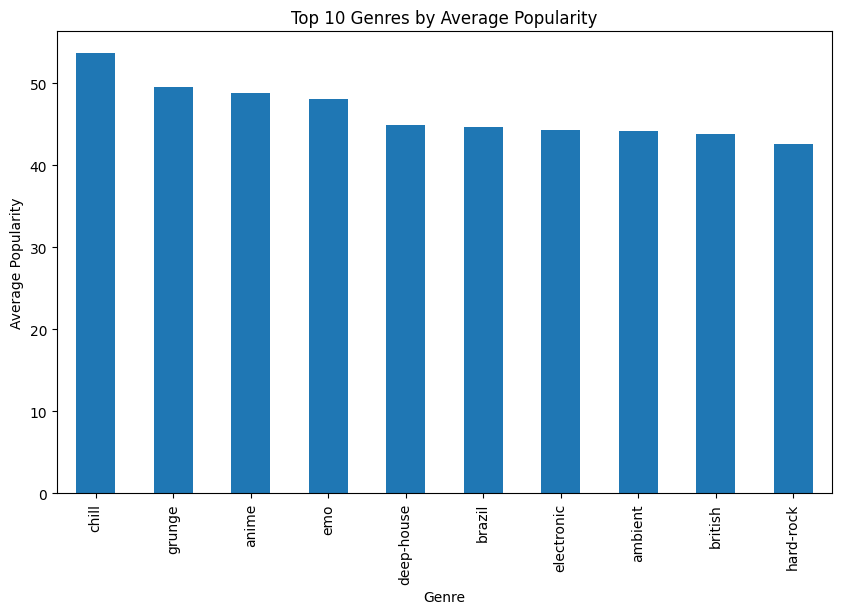

In [117]:
top10 = genre_popularity.head(10)

plt.figure(figsize=(10,6))
top10.plot(kind="bar")

plt.title("Top 10 Genres by Average Popularity")
plt.xlabel("Genre")
plt.ylabel("Average Popularity")

plt.show()

## Least Popular Genres

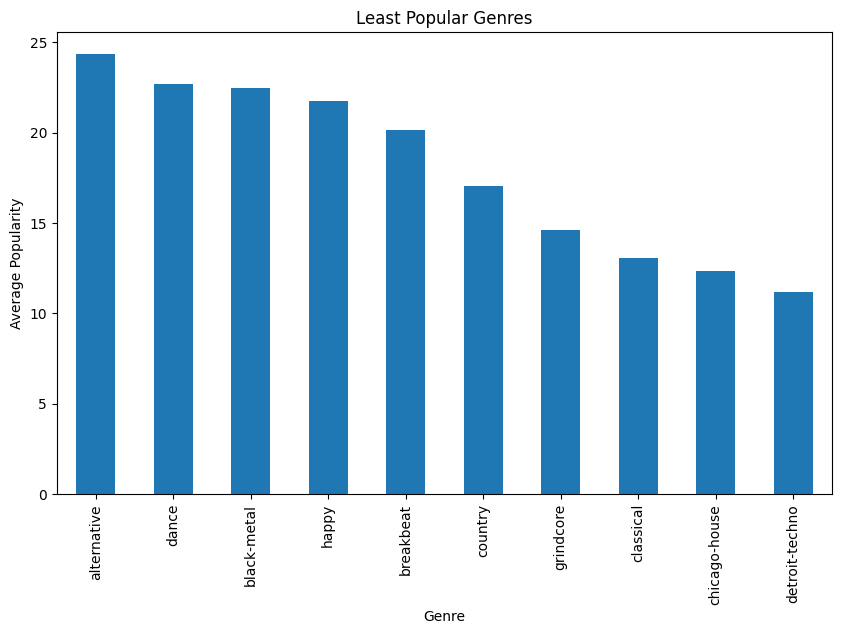

In [118]:
bottom10 = genre_popularity.tail(10)

plt.figure(figsize=(10,6))
bottom10.plot(kind="bar")

plt.title("Least Popular Genres")
plt.xlabel("Genre")
plt.ylabel("Average Popularity")

plt.show()

## Comparing Top and Low Popularity Songs

This section compares the average audio characteristics of highly popular and less popular tracks.

In [119]:
df["tempo"] = pd.to_numeric(df["tempo"], errors="coerce") #Convert the column to numeric
top_songs = df[df["popularity"] >= 80]
low_songs = df[df["popularity"] <= 20]

comparison = pd.DataFrame({
    "Top Songs": top_songs[
        ["danceability", "energy", "valence", "tempo", "acousticness"]
    ].mean(),
    "Low Popularity Songs": low_songs[
        ["danceability", "energy", "valence", "tempo", "acousticness"]
    ].mean()
})

comparison

,Top Songs,Low Popularity Songs
danceability,0.645487,0.568738
energy,0.688627,0.686585
valence,0.519550,0.462955
tempo,119.050497,123.112152
acousticness,0.160129,0.229975


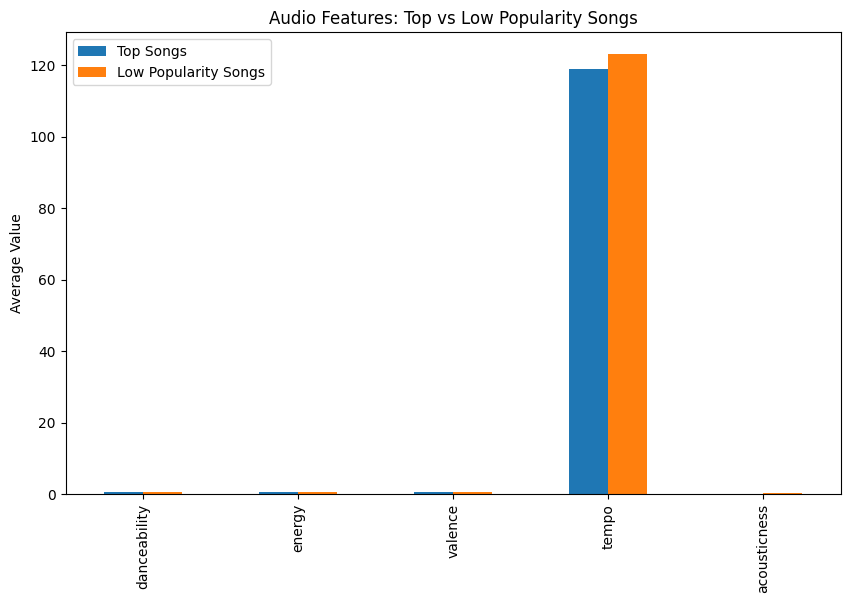

In [120]:
comparison.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title(
    "Audio Features: Top vs Low Popularity Songs"
)

plt.ylabel("Average Value")

plt.show()

# Key Findings

1. Popularity showed very weak correlation with individual audio features.

2. Instrumentalness had the strongest negative relationship with popularity.

3. Loudness showed a slight positive relationship with popularity.

4. Genre appeared to have a stronger influence on popularity than audio features.

5. Explicit and non-explicit songs showed differences in average popularity.

6. Audio features alone cannot fully explain why a song becomes popular.

# Conclusion

This analysis explored more than 114,000 Spotify tracks to understand the factors associated with popularity.

The results suggest that no single audio feature strongly predicts a song's success. While characteristics such as loudness, danceability, and instrumentalness show some relationship with popularity, these effects are relatively weak.

The findings indicate that popularity is likely influenced by factors beyond audio features, including artist reputation, marketing, playlist placement, social media trends, and listener behavior.

Therefore, creating a hit song appears to involve more than simply optimizing musical characteristics.